# Output 평가 노트북 — 4 케이스 × (MPC / RMPC / DPC)

- **케이스 4개**: `base / noise / dist / both`
- 각 케이스마다 **MPC·RMPC·DPC(epoch 0199)** 를 색만 달리해 겹쳐 그림 (행: temp / depth / laser power)
- 본인 metric(`collect_stats`: 구간별 추종오차 + depth 상한 위반)으로 세 컨트롤러 평가

**상단 셋업 셀의 경로/상수만 환경에 맞게 고치면 됩니다.**


## 0. 공통 셋업 (경로 · 스타일 · 로더)

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 폰트/스타일 (figure 코드 참고) =====
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
})

# ===== 케이스 / 상수 =====
CASES      = ["base", "noise", "dist", "both"]
DPC_EPOCH  = "0199"        # DPC 기준 epoch
LASER_ID   = 1

CUTOFF     = 201 - 20      # 플롯에서 뒤쪽 잘라낼 길이 (figure 코드와 동일)
SPLIT_IDX  = 2440          # metric 구간 분할
END_IDX    = 6050          # metric 끝
DEPTH_UB   = 0.225         # depth 상한 (위반 기준)
DEPTH_LB   = 0.075         # depth 하한
TEMP_DIV   = 2.0           # ★ cell25는 온도를 /2 했음. 그대로 재현하려면 2.0, 원본스케일이면 1.0

# ===== 경로 (★ 환경에 맞게 수정) =====
# MPC/RMPC: 8케이스 노트북 save_result 가 만든 profile_<MODE>_<case>.csv 라고 가정
MPC_RMPC_DIR = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_sensor_noise"
def mpc_csv(case):  return os.path.join(MPC_RMPC_DIR,  f"profile_MPC_{case}.csv")
def rmpc_csv(case): return os.path.join(MPC_RMPC_DIR, f"profile_RMPC_{case}.csv")

# DPC: run_epochs 노트북이 time/<case>/policy_roll_epoch0199.pth_clamped(1)/ 아래 저장
DPC_MODEL_DIR = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff"
def dpc_dir(case):
    return os.path.join(DPC_MODEL_DIR, "time", case, f"policy_roll_epoch{DPC_EPOCH}.pth_clamped(1)")

# laser power 로 무엇을 쓸지: 명령값(u_cmd) 우선, 없으면 LP/u_plant
LP_CANDIDATES = ["u_cmd", "LP", "u_plant"]

def _pick(df, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c].values
    return None

# ===== 로더: 공통 반환 = dict(temp, depth, lp, ref) (원본 전체 길이) =====
def load_mpc_like(path):
    """profile_*.csv (MPC/RMPC)"""
    df = pd.read_csv(path)
    return {
        "temp":  df["gamma_result_temp"].values,
        "depth": df["gamma_result_depth"].values,
        "ref":   df["ref"].values,
        "lp":    _pick(df, LP_CANDIDATES),
    }

def load_dpc(case):
    d = dpc_dir(case)
    df_x = pd.read_csv(os.path.join(d, f"x_outputs_laser_{LASER_ID}.csv"))   # col0=temp, col1=depth
    df_u = pd.read_csv(os.path.join(d, f"u_outputs_laser_{LASER_ID}.csv"))   # col0=lp(command)
    df_r = pd.read_csv(os.path.join(d, f"ref_laser_{LASER_ID}.csv"), header=None)         # col0=ref
    # u_cmd 파일이 따로 있으면 그것을 laser power 로 우선 사용
    u_cmd_path = os.path.join(d, f"u_cmd_laser_{LASER_ID}.csv")
    lp = pd.read_csv(u_cmd_path).iloc[:,0].values if os.path.exists(u_cmd_path) else df_u.iloc[:,0].values
    return {
        "temp":  df_x.iloc[:,0].values,
        "depth": df_x.iloc[:,1].values,
        "ref":   df_r.iloc[:,0].values,
        "lp":    lp,
    }

def load_all(case):
    """한 케이스에 대해 세 컨트롤러 로드. 파일 없으면 None."""
    out = {}
    for name, loader in [("MPC", lambda: load_mpc_like(mpc_csv(case))),
                         ("RMPC", lambda: load_mpc_like(rmpc_csv(case))),
                         ("DPC", lambda: load_dpc(case))]:
        try:
            out[name] = loader()
        except Exception as e:
            print(f"[WARN] {name} / {case}: {e}")
            out[name] = None
    return out

# 컨트롤러별 색/선스타일
COLOR = {"MPC": "black", "RMPC": "crimson", "DPC": "royalblue"}
STYLE = {"MPC": "-",     "RMPC": "--",      "DPC": "-"}
print("setup done. cases:", CASES)


setup done. cases: ['base', 'noise', 'dist', 'both']


## 1. 케이스별 오버레이 플롯 (temp / depth / laser power)

케이스 4개 → 그림 4개. 각 그림에서 MPC·RMPC·DPC 를 색만 달리해 겹침.

In [2]:
# def plot_case(case):
#     data = load_all(case)
#     fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
#                              gridspec_kw={"hspace": 0.08})
#     ax_t, ax_d, ax_u = axes

#     ref_drawn = False
#     # for name in ["MPC", "RMPC", "DPC"]:
#     for name in ["RMPC"]:
#         d = data.get(name)
#         if d is None:
#             continue
#         temp, depth, lp, ref = d["temp"], d["depth"], d["lp"], d["ref"]
#         N = min(len(temp), len(depth), len(ref), len(lp) if lp is not None else len(temp)) - CUTOFF
#         N = max(N, 0)
#         t = np.arange(N)

#         ax_t.plot(t, np.asarray(temp[:N])/TEMP_DIV, color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)
#         ax_d.plot(t, depth[:N], color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)
#         if lp is not None:
#             ax_u.plot(t, lp[:N], color=COLOR[name], ls=STYLE[name], lw=1.4, label=name)

#         if not ref_drawn:
#             ax_t.plot(t, np.asarray(ref[:N])/TEMP_DIV, ls=":", color="gray", lw=1.0, label="Reference")
#             ref_drawn = True

#     # depth 제약선
#     ax_d.axhline(DEPTH_UB, ls="--", color="0.3", lw=1.0)
#     ax_d.axhline(DEPTH_LB, ls="--", color="0.3", lw=1.0)

#     ax_t.set_ylabel("Melt Pool\nTemp (K)")
#     ax_d.set_ylabel("Melt Pool\nDepth (mm)")
#     ax_u.set_ylabel("Laser\nPower (W)")
#     ax_u.set_xlabel("Time Step")
#     for ax in axes:
#         ax.grid(True, alpha=0.3)
#     ax_t.legend(loc="lower right", ncol=2, frameon=True)
#     ax_t.set_title(f"Case: {case}")
#     plt.tight_layout()
#     plt.savefig(f"overlay_{case}.pdf", bbox_inches="tight", dpi=300)
#     plt.show()

# for case in CASES:
#     plot_case(case)


## 1.5 케이스별 그림을 하나로 합친 버전 (4행 스택)

네 케이스(base/noise/dist/both)를 **세로로 쌓아 하나의 그림**으로 그린다. 각 케이스 블록 = DPC/MPC/RMPC 3행 × **왼쪽 열(온도)+Reference**, **오른쪽 열(depth)+상/하한선**. 블록마다 `(a)`~`(d)` 라벨만 표기(기존 `(e)`~`(j)` 패널 라벨 제거).


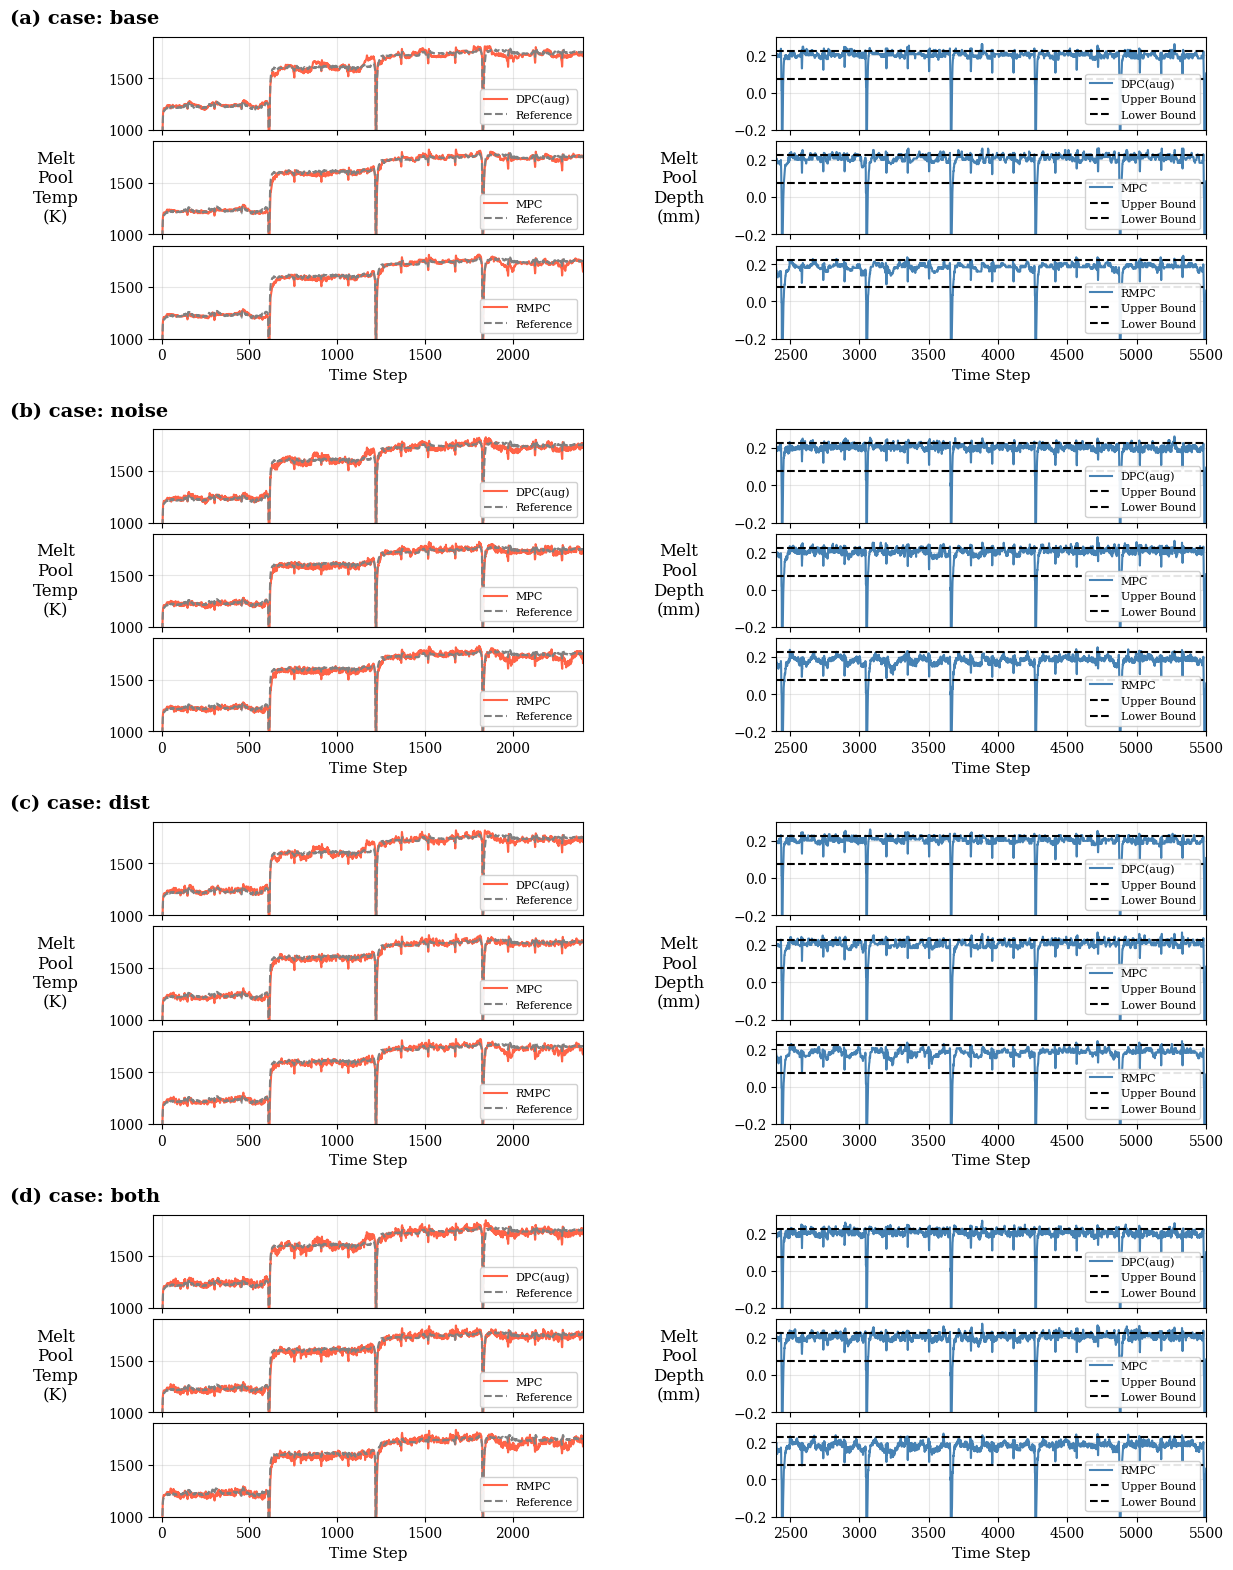

In [3]:
import matplotlib.gridspec as gridspec

# ── 4개 케이스를 세로로 쌓아 하나의 그림으로 (각 케이스 = DPC/MPC/RMPC 3행 × 온도|depth 2열) ──
# 케이스 라벨: (a) base, (b) noise, (c) dist, (d) both.  (e)~(j) 패널 라벨은 제거.
EFGHIJ_ORDER = ["DPC", "MPC", "RMPC"]                       # figure와 동일 순서
EFGHIJ_LABEL = {"DPC": "DPC(aug)", "MPC": "MPC", "RMPC": "RMPC"}

TEMP_COLOR   = "tomato"
DEPTH_COLOR  = "steelblue"

# 패널별 표시 구간/축범위 (None 이면 자동). figure 기본값.
TEMP_XLIM    = (-50, 2400)
DEPTH_XLIM   = (2400, 5500)
TEMP_YLIM    = (1000, 1900)
DEPTH_YLIM   = (-0.2, 0.3)

GROUP_YLABEL_SIZE = 12
CASE_LABEL_SIZE   = 14


def plot_EFGHIJ_all(cases=CASES, save=True):
    """모든 케이스를 세로로 쌓은 하나의 그림.
    각 케이스 블록 = DPC/MPC/RMPC 3행 × (왼쪽=온도+Reference, 오른쪽=depth+상/하한).
    블록마다 (a)~(d) 라벨 한 개만 표기."""
    fig = plt.figure(figsize=(13, 16))
    outer = fig.add_gridspec(len(cases), 1, hspace=0.3,
                             left=0.16, right=0.97, top=0.965, bottom=0.04)

    for ci, case in enumerate(cases):
        data = load_all(case)
        rows = [(name, data.get(name)) for name in EFGHIJ_ORDER]
        inner = outer[ci].subgridspec(3, 2, wspace=0.45, hspace=0.12)
        # axes[0:3] = 왼쪽열(온도),  axes[3:6] = 오른쪽열(depth)
        axes = [fig.add_subplot(inner[r, c]) for c in range(2) for r in range(3)]

        # ===== 왼쪽 열: Temperature =====
        for i, (name, d) in enumerate(rows):
            ax = axes[i]
            if d is not None:
                temp = np.asarray(d["temp"], dtype=float) / TEMP_DIV
                ref  = np.asarray(d["ref"],  dtype=float) / TEMP_DIV
                n = min(len(temp), len(ref))
                t = np.arange(n)
                ax.plot(t, temp[:n], color=TEMP_COLOR, label=EFGHIJ_LABEL[name])
                ax.plot(t, ref[:n], "--", color="gray", label="Reference")
            if TEMP_XLIM: ax.set_xlim(*TEMP_XLIM)
            if TEMP_YLIM: ax.set_ylim(*TEMP_YLIM)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Time Step") if i == 2 else ax.tick_params(labelbottom=False)
            ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9)

        # ===== 오른쪽 열: Depth =====
        for i, (name, d) in enumerate(rows):
            ax = axes[i + 3]
            if d is not None:
                depth = np.asarray(d["depth"], dtype=float)
                t = np.arange(len(depth))
                ax.plot(t, depth, color=DEPTH_COLOR, label=EFGHIJ_LABEL[name])
            if DEPTH_XLIM: ax.set_xlim(*DEPTH_XLIM)
            if DEPTH_YLIM: ax.set_ylim(*DEPTH_YLIM)
            xlo, xhi = DEPTH_XLIM if DEPTH_XLIM else ax.get_xlim()
            ax.hlines(DEPTH_UB, xlo, xhi, linestyle="--", color="black", label="Upper Bound")
            ax.hlines(DEPTH_LB, xlo, xhi, linestyle="--", color="black", label="Lower Bound")
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("Time Step") if i == 2 else ax.tick_params(labelbottom=False)
            ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.9)

        # ===== 그룹 y라벨 + 케이스 라벨(블록당 1개) =====
        pL_top, pL_bot = axes[0].get_position(), axes[2].get_position()
        pR_top, pR_bot = axes[3].get_position(), axes[5].get_position()
        fig.text(pL_top.x0 - 0.075, (pL_bot.y0 + pL_top.y1) / 2, "Melt\nPool\nTemp\n(K)",
                 ha="center", va="center", fontsize=GROUP_YLABEL_SIZE, linespacing=1.2)
        fig.text(pR_top.x0 - 0.075, (pR_bot.y0 + pR_top.y1) / 2, "Melt\nPool\nDepth\n(mm)",
                 ha="center", va="center", fontsize=GROUP_YLABEL_SIZE, linespacing=1.2)
        fig.text(pL_top.x0 - 0.11, pL_top.y1 + 0.006, f"({chr(97 + ci)}) case: {case}",
                 ha="left", va="bottom", fontsize=CASE_LABEL_SIZE, fontweight="bold")

    if save:
        plt.savefig("EFGHIJ_all_cases.pdf", bbox_inches="tight", dpi=300)
    plt.show()


plot_EFGHIJ_all()


## 2. 본인 metric 평가 (`collect_stats`)

구간1 `[0:2440]` / 구간2 `[2440:6050]` 추종오차 `|T-T_ref|` 의 mean·std,
그리고 depth 상한(0.225) 위반의 mean·std·count·rate 를 세 컨트롤러 × 4케이스로 계산.

In [4]:
def compute_metric(d, is_dpc):
    """업로드 노트북 CELL25 collect_stats 로직을 그대로 재현."""
    temp  = np.asarray(d["temp"], dtype=float)
    ref   = np.asarray(d["ref"],  dtype=float)
    depth = np.asarray(d["depth"], dtype=float)

    if is_dpc:
        ref   = ref[1:END_IDX]
        temp  = temp[:END_IDX]
        depth_for_viol = depth[:END_IDX]
    else:
        temp  = temp[:-1]
        ref   = ref[:-1]
        depth_for_viol = depth[:-1]

    n = min(len(ref), len(temp))
    temp, ref = temp[:n], ref[:n]

    dist = np.abs(temp/TEMP_DIV - ref/TEMP_DIV)
    p1 = dist[:SPLIT_IDX]
    p2 = dist[SPLIT_IDX:END_IDX]

    v = depth_for_viol - DEPTH_UB
    v = v[v > 0]

    return {
        "temp1_mean": np.mean(p1) if len(p1) else np.nan,
        "temp1_std":  np.std(p1)  if len(p1) else np.nan,
        "temp2_mean": np.mean(p2) if len(p2) else np.nan,
        "temp2_std":  np.std(p2)  if len(p2) else np.nan,
        "viol_mean":  np.mean(v)  if len(v)  else 0.0,
        "viol_std":   np.std(v)   if len(v)  else 0.0,
        "viol_count": int(len(v)),
        "viol_rate":  len(v)/len(depth_for_viol) if len(depth_for_viol) else 0.0,
    }

rows = []
for case in CASES:
    data = load_all(case)
    for name in ["MPC", "RMPC", "DPC"]:
        d = data.get(name)
        if d is None:
            continue
        m = compute_metric(d, is_dpc=(name == "DPC"))
        m = {"case": case, "method": name, **m}
        rows.append(m)

stats = pd.DataFrame(rows)
stats = stats[["case","method","temp1_mean","temp1_std","temp2_mean","temp2_std",
               "viol_mean","viol_std","viol_count","viol_rate"]]

import math

def sig3(v, n=4):
    """유효숫자 n자리로 반올림 (0/NaN/inf 는 그대로)."""
    if v is None or pd.isna(v) or v == 0 or not math.isfinite(v):
        return v
    return round(v, -int(math.floor(math.log10(abs(v)))) + (n - 1))

# 정수로 둘 컬럼은 제외하고 유효숫자 3자리 적용
int_cols   = ["viol_count"]
float_cols = [c for c in stats.columns
              if c not in (["case", "method"] + int_cols)
              and pd.api.types.is_numeric_dtype(stats[c])]

stats[float_cols] = stats[float_cols].applymap(sig3)

# ===== method 끼리 모아서 정렬 (MPC -> RMPC -> DPC, 각 그룹 안에서 case 순서 유지) =====
method_order = pd.Categorical(stats["method"], categories=["MPC", "RMPC", "DPC"], ordered=True)
case_order   = pd.Categorical(stats["case"],   categories=CASES, ordered=True)
stats = (stats.assign(_m=method_order, _c=case_order)
              .sort_values(["_m", "_c"])
              .drop(columns=["_m", "_c"])
              .reset_index(drop=True))

stats.to_csv("comparison_stats_4cases.csv", index=False)
print("saved comparison_stats_4cases.csv")
stats


saved comparison_stats_4cases.csv


/tmp/ipykernel_1913105/1554655407.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats[float_cols] = stats[float_cols].applymap(sig3)


,case,method,temp1_mean,temp1_std,temp2_mean,temp2_std,viol_mean,viol_std,viol_count,viol_rate
0,base,MPC,20.25,40.52,120.1,60.15,0.009855,0.008180,561,0.090560
1,noise,MPC,22.23,39.98,123.9,58.90,0.008695,0.008041,398,0.064250
2,dist,MPC,22.10,40.85,122.2,59.98,0.009108,0.007094,477,0.077000
3,both,MPC,24.70,40.87,124.8,59.16,0.009448,0.008409,375,0.060530
4,base,RMPC,23.31,43.57,165.5,57.34,0.008781,0.005391,19,0.003067
5,noise,RMPC,27.51,43.47,171.8,57.23,0.005651,0.005963,35,0.005650
6,dist,RMPC,26.48,44.08,169.7,58.37,0.007806,0.005826,20,0.003228
7,both,RMPC,30.30,43.67,173.5,58.86,0.007818,0.005852,33,0.005327
8,base,DPC,26.23,42.68,130.2,62.33,0.008024,0.006818,190,0.031400
9,noise,DPC,27.19,42.48,130.2,63.44,0.008970,0.007343,216,0.035700


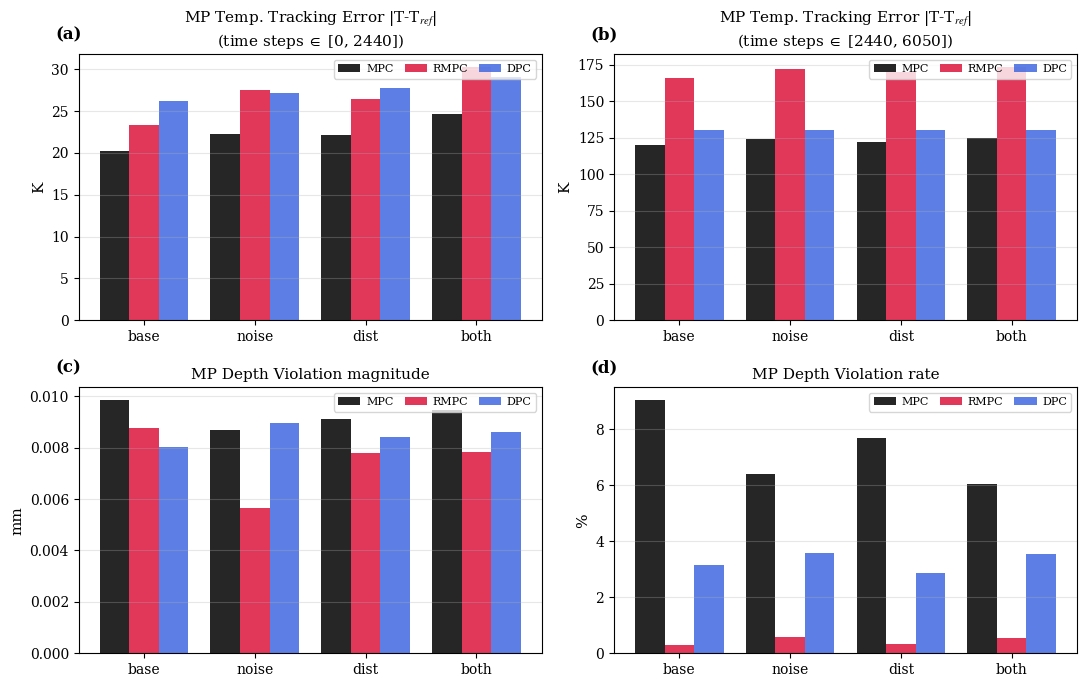

In [5]:
# ── stats 시각화: 케이스 x축, 컨트롤러별 막대, std 는 에러바 ──
METHOD_ORDER = ["MPC", "RMPC", "DPC"]

def plot_stats(stats, save=True):
    methods = [m for m in METHOD_ORDER if m in stats["method"].unique()]
    cases   = [c for c in CASES if c in stats["case"].unique()]
    x = np.arange(len(cases))
    w = 0.8 / max(len(methods), 1)

    def grab(method, col):
        sub = stats[stats["method"] == method].set_index("case")
        return np.array([sub.loc[c, col] if c in sub.index else np.nan for c in cases], float)

    # (값컬럼, std컬럼 or None, 제목, 단위)
    panels = [
        ("temp1_mean", "temp1_std", r"MP Temp. Tracking Error |T-T$_{ref}$|" + "\n" + r"(time steps $\in$ [0, 2440])", "K"),
        ("temp2_mean", "temp2_std", r"MP Temp. Tracking Error |T-T$_{ref}$|" + "\n" + r"(time steps $\in$ [2440, 6050])", "K"),
        ("viol_mean",  "viol_std",  "MP Depth Violation magnitude",              "mm"),
        ("viol_rate",  None,        "MP Depth Violation rate",                    "%"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    axes = axes.ravel()
    for i, (ax, (mcol, scol, title, unit)) in enumerate(zip(axes, panels)):
        for k, method in enumerate(methods):
            vals = grab(method, mcol)
            errs = grab(method, scol) if scol else None
            if unit == "%":
                vals = vals * 100.0
            ax.bar(x + (k - (len(methods) - 1) / 2) * w, vals, w,
                   
                   capsize=3, color=COLOR.get(method, None),
                   alpha=0.85, label=method, error_kw=dict(lw=1, alpha=0.6))
        ax.set_title(title)
        ax.text(-0.05, 1.04, f"({chr(97 + i)})", transform=ax.transAxes,
                fontsize=12, fontweight="bold", va="bottom", ha="left")
        ax.set_ylabel(unit)
        ax.set_xticks(x); ax.set_xticklabels(cases)
        ax.grid(True, axis="y", alpha=0.3)
        # ★ 각 패널마다 한 행(가로)으로 legend
        ax.legend(ncol=len(methods), loc="upper right", frameon=True,
                  fontsize=8, columnspacing=1.0, handletextpad=0.5)
    fig.tight_layout()
    if save:
        fig.savefig("stats_comparison.pdf", bbox_inches="tight", dpi=300)
    plt.show()

plot_stats(stats)

In [6]:
import os
import numpy as np
import pandas as pd

DIR_A = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)"
DIR_B = DIR_A + "_SEC"

# 비교할 CSV 파일들 (있는 것만 비교)
files = [
    "x_outputs_laser_1.csv",
    "u_outputs_laser_1.csv",
    "ref_laser_1.csv",
    "x_true_outputs_laser_1.csv",
    "u_cmd_laser_1.csv",
    "u_plant_laser_1.csv",
    "disturbance_laser_1.csv",
]

def load(path):
    # 헤더 유무가 파일마다 다를 수 있어 양쪽 다 시도
    df = pd.read_csv(path)
    return df.apply(pd.to_numeric, errors="coerce").values

print(f"A: {DIR_A}")
print(f"B: {DIR_B}\n")
print(f"{'file':28s} {'shapeA':>12s} {'shapeB':>12s} {'max|Δ|':>12s} {'mean|Δ|':>12s} {'max rel%':>10s}")
print("-"*90)

for fn in files:
    pa, pb = os.path.join(DIR_A, fn), os.path.join(DIR_B, fn)
    if not (os.path.exists(pa) and os.path.exists(pb)):
        miss = "A" if not os.path.exists(pa) else "B"
        print(f"{fn:28s}  (없음: {miss} 쪽)")
        continue

    a, b = load(pa), load(pb)

    if a.shape != b.shape:
        n = min(a.shape[0], b.shape[0])
        m = min(a.shape[1], b.shape[1])
        print(f"{fn:28s} {str(a.shape):>12s} {str(b.shape):>12s}   shape 다름 → [:{n},:{m}]로 잘라 비교")
        a, b = a[:n, :m], b[:n, :m]

    diff = np.abs(a - b)
    denom = np.maximum(np.abs(a), 1e-12)
    rel = np.nanmax(diff / denom) * 100
    print(f"{fn:28s} {str(a.shape):>12s} {str(b.shape):>12s} {np.nanmax(diff):12.6g} {np.nanmean(diff):12.6g} {rel:10.3f}")

# ===== 컬럼별(온도/depth) 상세: x_outputs =====
pa, pb = os.path.join(DIR_A, "x_outputs_laser_1.csv"), os.path.join(DIR_B, "x_outputs_laser_1.csv")
if os.path.exists(pa) and os.path.exists(pb):
    a, b = load(pa), load(pb)
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    print("\n[x_outputs 컬럼별]")
    for j, name in enumerate(["temp", "depth"]):
        if j < a.shape[1]:
            d = np.abs(a[:, j] - b[:, j])
            print(f"  {name:6s}  max|Δ|={d.max():.6g}  mean|Δ|={d.mean():.6g}  "
                  f"std_A={np.nanstd(a[:,j]):.4g} std_B={np.nanstd(b[:,j]):.4g}  "
                  f"첫 분기 idx={int(np.argmax(d>1e-9)) if np.any(d>1e-9) else '없음'}")

A: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)
B: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/base/policy_roll_epoch0199.pth_clamped(1)_SEC

file                               shapeA       shapeB       max|Δ|      mean|Δ|   max rel%
------------------------------------------------------------------------------------------
x_outputs_laser_1.csv           (6245, 2)    (6245, 2)      101.676      7.28407 612244899999.998
u_outputs_laser_1.csv           (6245, 1)    (6245, 1)      18.1696      1.39509      3.252
ref_laser_1.csv                 (6295, 1)    (6295, 1)

found 9 cases
    temp1_mean  temp1_std  temp2_mean  temp2_std  viol_mean  viol_std  \
0    49.491985  65.761576  134.195369  67.117409   0.008438  0.006201   
1    33.567837  54.596045  132.301952  66.944885   0.008647  0.006760   
2    41.392419  58.738945  128.269208  67.343577   0.007532  0.005265   
3    46.396207  60.506203  126.645448  65.914918   0.007305  0.005386   
4    44.607622  54.694643  155.104245  65.266135   0.009466  0.006611   
5    43.566771  52.718932  153.696486  64.712789   0.008512  0.006928   
6    70.471732  74.517981  138.271208  66.032800   0.008077  0.006222   
7    42.970199  57.004859  138.585792  64.982684   0.009554  0.008457   
8    42.595584  55.231929  134.982299  68.000210   0.008692  0.006448   
9    32.124228  54.121884  131.669045  66.787109   0.008431  0.007426   
10   47.234641  57.559466  134.062969  64.779486   0.008099  0.005622   
11   67.866897  81.854338  126.149289  66.997350   0.008569  0.006578   
12   41.678626  56.935794  126.048843

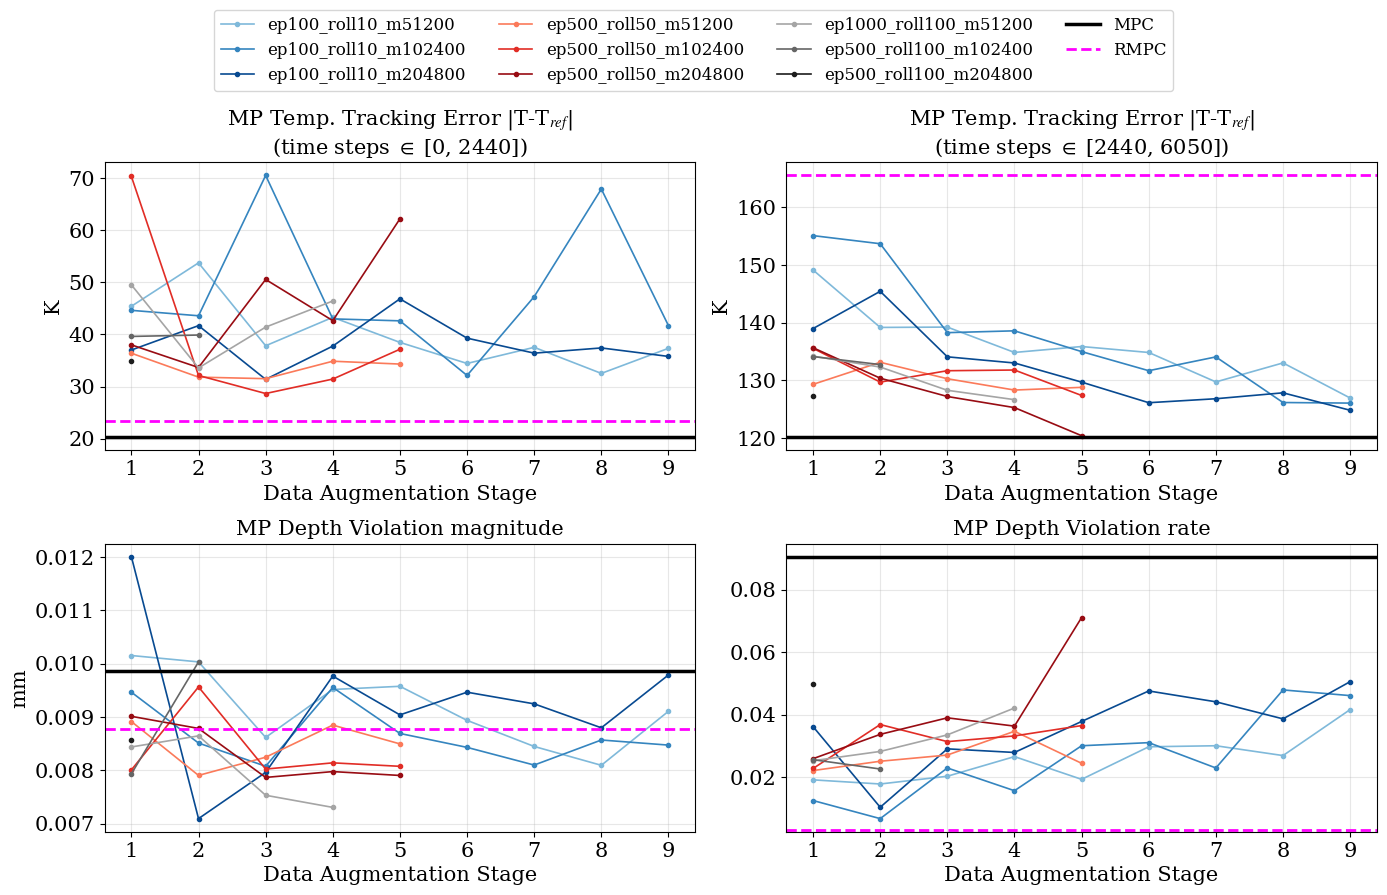


===== BEST CHECKPOINT PER CASE =====
                   label  roll  stage  epoch  rank_sum  temp1_mean  \
0    ep100_roll10_m51200    10      8     89      11.0   32.517681   
1   ep100_roll10_m102400    10      6     69      14.0   32.124228   
2   ep100_roll10_m204800    10      3     39      13.0   31.376693   
3    ep500_roll50_m51200    50      5    299      10.0   34.307693   
4   ep500_roll50_m102400    50      3    199       8.0   28.660368   
5   ep500_roll50_m204800    50      2    149      11.0   33.650807   
6  ep1000_roll100_m51200   100      3    399       9.0   41.392419   
7  ep500_roll100_m102400   100      2    299       6.0   39.872102   
8  ep500_roll100_m204800   100      1    199       4.0   34.886830   

   temp2_mean  viol_mean  viol_rate  
0  133.020687   0.008094   0.026947  
1  131.669045   0.008431   0.031080  
2  134.076610   0.007962   0.029096  
3  128.782383   0.008496   0.024467  
4  131.665928   0.008024   0.031410  
5  130.370561   0.008786   0.0337

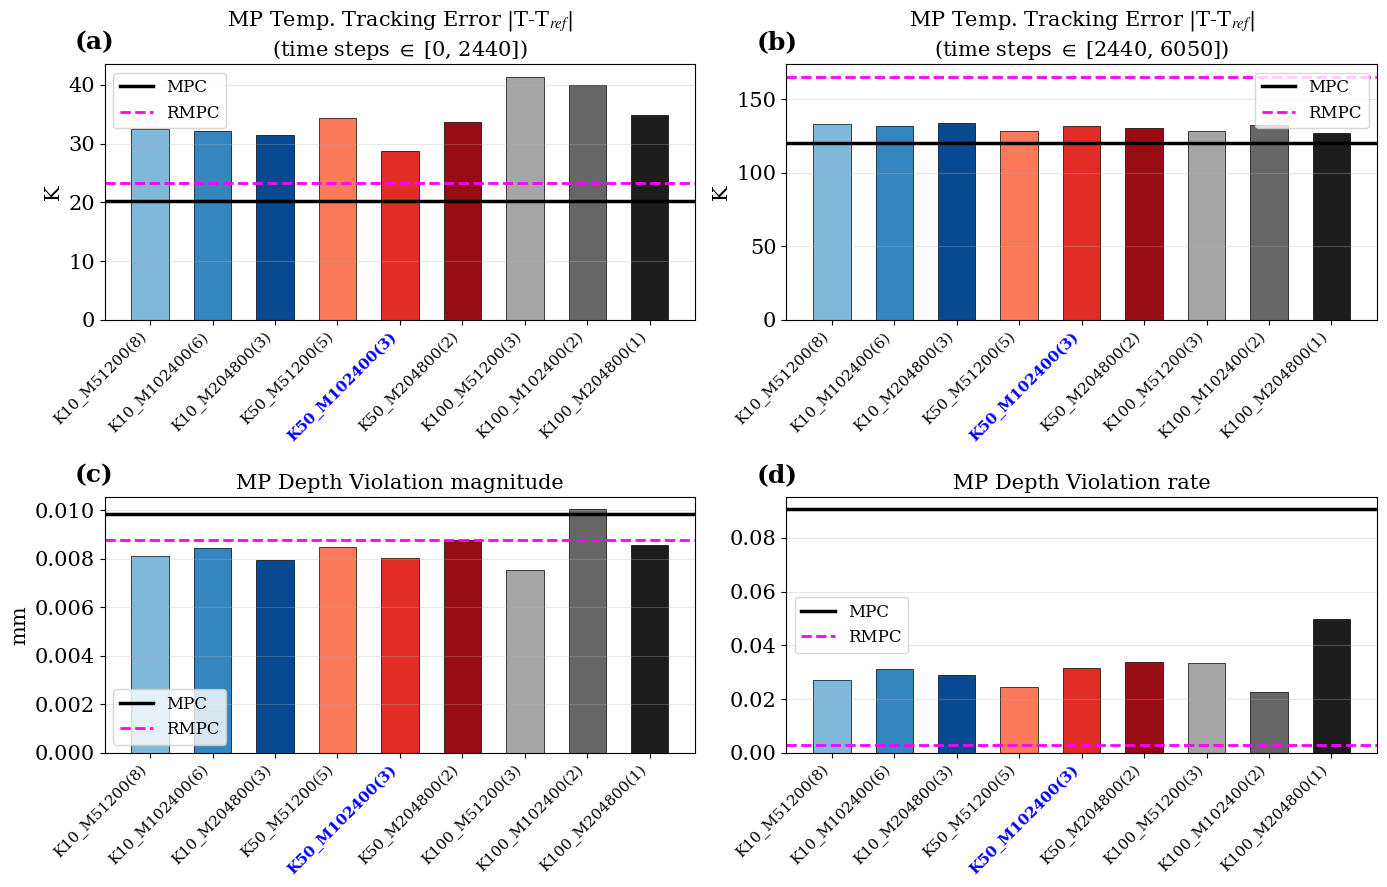

In [7]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 경로 =====
base_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_0705"

mpc_csv  = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_MPC_w_depth_control_0925.csv"
rmpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"

laser_id = 1
D_MAX = 0.225

# ===== 통계 함수 =====
def compute_stats(temp, ref, depth):
    dist = np.abs(temp - ref)
    p1 = dist[:2440]
    p2 = dist[2440:6050]

    v = depth - D_MAX
    v = v[v > 0]

    return {
        "temp1_mean": np.mean(p1),
        "temp1_std":  np.std(p1),
        "temp2_mean": np.mean(p2),
        "temp2_std":  np.std(p2),
        "viol_mean":  np.mean(v) if len(v) > 0 else 0,
        "viol_std":   np.std(v) if len(v) > 0 else 0,
        "viol_count": len(v),
        "viol_rate":  len(v) / len(depth),
    }

# ===== case 라벨 축약 / roll 파싱 =====
def short_label(case_name):
    m = re.search(r"ep(\d+)_roll(\d+)_m(\d+)", case_name)
    if m:
        ep, roll, mem = m.groups()
        return f"ep{ep}_roll{roll}_m{mem}"
    return case_name[:40]

def get_roll(case_name):
    m = re.search(r"roll(\d+)", case_name)
    return int(m.group(1)) if m else None

def get_m(case_name):
    m = re.search(r"_m(\d+)", case_name)
    return int(m.group(1)) if m else 0

def epoch_to_stage(epoch, roll):
    # roll=10: epoch 9 -> stage 0, 19 -> 1, ...
    # roll=50: epoch 49 -> stage 0, 99 -> 1, ...
    if (epoch + 1) % roll != 0:
        return None  # rollout 경계가 아닌 epoch은 제외
    return (epoch + 1) // roll - 1

# ===== MPC / RMPC baseline =====
def load_baseline(csv_path):
    df = pd.read_csv(csv_path)
    temp  = df["gamma_result_temp"].values[:-1] / 2
    ref   = df["ref"].values[:-1] / 2
    depth = df["gamma_result_depth"].values[:-1]
    return compute_stats(temp, ref, depth)

mpc_stats  = load_baseline(mpc_csv)
rmpc_stats = load_baseline(rmpc_csv)

# ===== DPC: case × epoch 수집 =====
records = []
case_dirs = sorted(glob.glob(os.path.join(base_dir, "or_*")))
print(f"found {len(case_dirs)} cases")

for case_dir in case_dirs:
    case_name = os.path.basename(case_dir)
    roll = get_roll(case_name)
    if roll is None:
        print(f"⚠️ roll 파싱 실패, skip: {case_name}")
        continue

    epoch_dirs = sorted(glob.glob(os.path.join(case_dir, "laser1_eval", "policy_roll_epoch*")))

    for ep_dir in epoch_dirs:
        m = re.search(r"epoch(\d+)", os.path.basename(ep_dir))
        if m is None:
            continue
        epoch = int(m.group(1))

        stage = epoch_to_stage(epoch, roll)
        if stage is None:
            continue

        ref_file  = os.path.join(ep_dir, f"ref_laser_{laser_id}.csv")
        temp_file = os.path.join(ep_dir, f"x_outputs_laser_{laser_id}.csv")
        if not (os.path.exists(ref_file) and os.path.exists(temp_file)):
            continue

        ref = pd.read_csv(ref_file).iloc[:, 0].values / 2
        df_temp = pd.read_csv(temp_file)
        temp  = df_temp.iloc[:, 0].values / 2
        depth = df_temp.iloc[:, 1].values

        ref   = ref[1:6050]
        temp  = temp[:6050]
        depth = depth[:6050]

        min_len = min(len(ref), len(temp), len(depth))
        ref, temp, depth = ref[:min_len], temp[:min_len], depth[:min_len]

        stats = compute_stats(temp, ref, depth)
        stats.update({"case": case_name, "label": short_label(case_name),
                      "epoch": epoch, "roll": roll, "m": get_m(case_name),
                      "stage": stage})
        records.append(stats)

df = pd.DataFrame(records).sort_values(["case", "stage"]).reset_index(drop=True)

# ===== stage 0 제외 (기본) =====
EXCLUDE_STAGE0 = True
if EXCLUDE_STAGE0:
    df = df[df["stage"] > 0].reset_index(drop=True)

df.to_csv("epoch_stats_all_cases.csv", index=False)
print(df)

# ===== 시각화: epoch에 따른 metric 추이 =====
metrics = [
    ("temp1_mean", "MP Temp. Tracking Error |T-T$_{ref}$|" + "\n" + r"(time steps $\in$ [0, 2440])", "K"),
    ("temp2_mean", "MP Temp. Tracking Error |T-T$_{ref}$|" + "\n" + r"(time steps $\in$ [2440, 6050])", "K"),
    ("viol_mean",  "MP Depth Violation magnitude", "mm"),
    ("viol_rate",  "MP Depth Violation rate", ""),
]
# ===== roll 그룹별 색상 계열 =====
# roll10 -> 파란 계열, roll50 -> 빨간 계열, roll100 -> 회색 계열
roll_cmaps = {10: plt.get_cmap("Blues"),
              50: plt.get_cmap("Reds"),
              100: plt.get_cmap("Greys")}

label_info = (df[["label", "roll", "m"]].drop_duplicates()
                .sort_values(["roll", "m"]).reset_index(drop=True))

color_map = {}
for roll, g in label_info.groupby("roll"):
    cm = roll_cmaps.get(roll, plt.get_cmap("Greens"))
    n = len(g)
    for j, label in enumerate(g["label"]):
        # 0.45 ~ 0.9 구간의 진하기로 그룹 내 구분
        shade = 0.45 + 0.45 * (j / max(n - 1, 1))
        color_map[label] = cm(shade)

plt.rcParams.update({
    "axes.titlesize": 15,   # 1.5x
    "axes.labelsize": 15,   # x/y axis labels
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (ax, (key, title, unit)) in enumerate(zip(axes, metrics)):
    for label in label_info["label"]:  # roll 순서로 legend 정렬
        g = df[df["label"] == label].sort_values("stage")
        ax.plot(g["stage"], g[key], marker='o', markersize=3,
                linewidth=1.2, color=color_map[label], label=label)

    # baseline
    ax.axhline(mpc_stats[key],  color='black',   linestyle='-',  linewidth=2.5, label="MPC")
    ax.axhline(rmpc_stats[key], color='magenta', linestyle='--', linewidth=2.0, label="RMPC")

    ax.set_title(title)
    ax.set_xlabel("Data Augmentation Stage")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_ylabel(unit)
    ax.grid(alpha=0.3)

# legend 하나만 (밖으로)
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=4,
           fontsize=12, bbox_to_anchor=(0.5, 1.0))

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("epoch_stats_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

# =====================================================
# ===== case별 best checkpoint 선정 (rank 합산) =====
# =====================================================
rank_metrics = ["temp1_mean", "temp2_mean", "viol_mean", "viol_rate"]

for key in rank_metrics:
    # 각 case 내부에서 stage들끼리 순위 매김 (낮을수록 좋음 -> rank 1이 best)
    df[f"rank_{key}"] = df.groupby("case")[key].rank(method="average")

df["rank_sum"] = df[[f"rank_{k}" for k in rank_metrics]].sum(axis=1)

# rank_sum 최소인 stage 선택 (동점이면 viol_rate 낮은 쪽)
best_idx = (df.sort_values(["rank_sum", "viol_rate"])
              .groupby("case").head(1).index)
df_best = df.loc[best_idx].sort_values(["roll", "m"]).reset_index(drop=True)

print("\n===== BEST CHECKPOINT PER CASE =====")
print(df_best[["label", "roll", "stage", "epoch", "rank_sum"] + rank_metrics])
df_best.to_csv("best_checkpoints.csv", index=False)

# ===== best 9개 비교 시각화 =====
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
axes2 = axes2.flatten()

x = np.arange(len(df_best))
def pretty_label(lbl):
    lbl = re.sub(r"^ep\d+_", "", lbl)       # remove ep***_
    lbl = lbl.replace("roll", "K")            # roll -> K
    lbl = re.sub(r"_m(\d+)", r"_M\1", lbl)    # size m -> M
    return lbl

bar_labels = [f"{pretty_label(row.label)}({row.stage})" for row in df_best.itertuples()]

HIGHLIGHT_CASE = "K50_M102400"

for i, (ax, (key, title, unit)) in enumerate(zip(axes2, metrics)):
    ax.text(-0.05, 1.04, f"({chr(97 + i)})", transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="bottom", ha="left")
    bars = ax.bar(x, df_best[key],
                  color=[color_map[l] for l in df_best["label"]],
                  width=0.6, edgecolor='black', linewidth=0.5)

    ax.axhline(mpc_stats[key],  color='black',   linestyle='-',  linewidth=2.5, label="MPC")
    ax.axhline(rmpc_stats[key], color='magenta', linestyle='--', linewidth=2.0, label="RMPC")

    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=11)

    # highlight 대상 case는 파란색 bold
    for tick in ax.get_xticklabels():
        if HIGHLIGHT_CASE in tick.get_text():
            tick.set_color('blue')
            tick.set_fontweight('bold')

    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("best_checkpoints_comparison.png", dpi=200, bbox_inches='tight')
plt.show()
